## DiD main purpose

**After validate the accuracy and liability of the prediction model, the next step is to focus more on the policy-oreiented issues.**

After validating the accuracy and reliability of the prediction model, the next step is to shift the focus towards policy-oriented analysis. The real-world objective is not only to assess current short-term rental licensure, but also to explore regulatory strategies that can effectively mitigate their negative impacts on the housing market, urban environment, and broader society.

Therefore, the purpose of the model is not limited to predicting licensure status; more importantly, it serves as a tool to identify which policy interventions are effective, which aspects they influence most, and how they shape the behavior of the short-term rental market.

Through this approach, we aim to establish a comprehensive framework that begins with accurate prediction and extends all the way to actionable policy guidance. By linking model-driven insights with real-world regulatory needs, the framework is designed to assist policymakers, planners, and other stakeholders in identifying which specific attributes of the short-term rental market require targeted intervention.

Ultimately, it enables stakeholders to focus on the aspects most relevant to their goals—whether it’s improving compliance, reducing housing pressure, or protecting neighborhood integrity—and adjust policies accordingly to achieve more balanced and effective outcomes.

In [98]:
# Load libraries
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.api as sm

sns.set_style('darkgrid')
import math
from sklearn.linear_model import LogisticRegression
from scipy import stats

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

from license_model import LicenseModel

In [99]:
Toronto_coefficients = pd.read_csv(os.path.join('results', 'toronto_airbnb_coefficients.csv'), index_col=0)
Vancouver_coefficients = pd.read_csv(os.path.join('results', 'Vancouver_airbnb_coefficients.csv'), index_col=0)
Quebec_coefficients = pd.read_csv(os.path.join('results', 'Quebec_airbnb_coefficients.csv'), index_col=0)


In [100]:
Quebec_coefficients

,202405,202406,202407,202408,202409,202410,202411,202412,202501,202502,202503,202504
accommodates,4.878472,0.013876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability_30,3.297424,0.028891,0.024709,0.027443,0.029056,5.477390,0.052901,0.037516,0.062053,9.946271e-03,8.452735e-03,2.456298e-02
availability_365,0.203514,0.570706,0.552966,0.532051,0.610982,0.224520,0.672272,0.657937,0.698281,1.581052e-01,9.068438e-02,1.993946e-01
availability_90,-2.416217,0.125584,0.121501,0.123887,0.151819,-1.038733,0.180555,0.172195,NaN,5.771996e-02,3.559867e-02,6.492514e-02
bathrooms,23.957242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,-24.038360,0.005043,0.004637,0.004665,0.004700,3.181013,0.004936,0.004767,0.004941,2.123057e-03,1.801129e-03,2.330786e-03
beds,14.080735,0.006862,0.006747,0.006606,0.006653,18.435892,0.006933,0.006717,0.006889,1.891642e-03,1.461687e-03,2.692622e-03
calculated_host_listings_count_private_rooms,14.796272,0.001905,0.001446,0.001867,0.001796,0.415703,0.001640,0.001627,0.001590,1.706550e-03,1.805703e-03,1.055152e-05
calculated_host_listings_count_shared_rooms,NaN,0.000665,NaN,NaN,NaN,0.013422,0.000523,0.000749,NaN,NaN,NaN,NaN
estimated_occupancy_l365d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.003881e-03,NaN,NaN


In [101]:
Vancouver_coefficients.columns = pd.to_datetime(Vancouver_coefficients.columns, format='%Y%m').strftime('%Y-%m')
Quebec_coefficients.columns = pd.to_datetime(Quebec_coefficients.columns, format='%Y%m').strftime('%Y-%m')
Toronto_coefficients.columns = pd.to_datetime(Toronto_coefficients.columns).strftime('%Y-%m')

In [102]:
# only remain the rows without NaN values
Toronto_coefficients_1 = Toronto_coefficients.dropna()
Vancouver_coefficients_1 = Vancouver_coefficients.dropna()
Quebec_coefficients_1 = Quebec_coefficients.dropna()

In [103]:
# check the list of common rows index with the intersection of the two dataframes
common_index = Toronto_coefficients_1.index.intersection(Vancouver_coefficients_1.index)
common_index = common_index.intersection(Quebec_coefficients_1.index)
common_index

Index(['host_is_superhost', 'bedrooms', 'minimum_nights', 'availability_30',
       'availability_365', 'number_of_reviews', 'number_of_reviews_l30d',
       'instant_bookable', 'calculated_host_listings_count_private_rooms',
       'room_type_Private room'],
      dtype='object')

In [104]:
Vancouver_common = Vancouver_coefficients_1.loc[common_index]
Toronto_common = Toronto_coefficients_1.loc[common_index]
Quebec_common = Quebec_coefficients_1.loc[common_index]
# drop the '2025-05' column of the toronto dataframe
Toronto_common = Toronto_common.drop(columns=['2025-05'])
Toronto_common

,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04
host_is_superhost,-0.048834,-0.205287,-0.186373,0.022533,-0.288232,-0.248164,-0.190506,-0.477881,-0.582392,-0.715130,-0.280938
bedrooms,-0.262920,-0.276421,-0.196249,-0.230845,-0.161400,-0.288219,-0.340529,-0.177752,-0.092684,-0.350495,-0.335644
minimum_nights,0.088138,0.127827,0.032934,0.056342,0.084148,0.153117,0.159644,0.167556,0.133555,0.118459,0.059766
availability_30,0.001044,0.010532,-0.008273,-0.033884,-0.015787,-0.000968,-0.008834,-0.009254,-0.010405,-0.004475,-0.028507
availability_365,0.000648,0.001803,0.001512,0.001232,0.000568,-0.000280,-0.000256,0.000292,-0.000432,-0.000573,0.000021
number_of_reviews,0.003427,0.003208,0.003955,0.002085,0.004607,0.005316,0.002807,0.001416,-0.002184,-0.001843,-0.001833
number_of_reviews_l30d,0.218052,0.226047,0.147398,0.117273,0.202528,0.111321,0.128802,-0.016396,-0.031246,-0.051089,-0.113461
instant_bookable,-0.407064,-0.104319,-0.239894,-0.110629,-0.481497,-0.204338,-0.204347,-0.225532,-0.319933,-0.354871,-0.013961
calculated_host_listings_count_private_rooms,-0.350231,-0.283580,-0.242650,-0.471908,-0.317153,-0.275847,-0.243139,-0.110380,-0.140292,-0.050428,-0.087268
room_type_Private room,3.324803,3.172253,3.068807,4.595241,3.367672,3.001712,3.239388,2.069099,1.970272,1.916570,1.541571


In [105]:
import pandas as pd

# add a 'city' column to each dataframe
vancouver_long = Vancouver_common.copy()
vancouver_long['city'] = 'Vancouver'

toronto_long = Toronto_common.copy()
toronto_long['city'] = 'Toronto'

quebec_long = Quebec_common.copy()
quebec_long['city'] = 'Quebec'


# concatenate the three dataframes
combined_df = pd.concat([vancouver_long, toronto_long, quebec_long], axis=0)

# Reset index to get 'variable' column
combined_df = combined_df.reset_index().rename(columns={'index': 'variable'})

# Melt the dataframe to long format
did_df = combined_df.melt(
    id_vars=['variable', 'city'], 
    var_name='time', 
    value_name='coef'
)



In [106]:
# convert 'time' column to datetime format
did_df['time'] = pd.to_datetime(did_df['time'], format='%Y-%m')

# --------------
# add a 'post_treatment' column to indicate whether the time is after the treatment period (2025-01)
# --------------
did_df['post_treatment'] = (did_df['time'] >= pd.to_datetime('2025-01')).astype(int)

# label the treatment group (Toronto) and control group (Vancouver and Quebec)
did_df['is_treatment'] = (did_df['city'] == 'Toronto').astype(int)


In [107]:
import statsmodels.formula.api as smf

# exteded model with variable-specific effects
model_variable_specific = smf.ols(
    formula="coef ~ post_treatment * is_treatment + C(variable) + C(time) + C(city)",
    data=did_df
).fit(cov_type='HC3')  # use the HC3 covariance estimator for robust standard errors

print(model_variable_specific.summary())


                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     1.092
Date:                Tue, 10 Jun 2025   Prob (F-statistic):              0.352
Time:                        13:29:46   Log-Likelihood:                -770.16
No. Observations:                 340   AIC:                             1588.
Df Residuals:                     316   BIC:                             1680.
Df Model:                          23                                         
Covariance Type:                  HC3                                         
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [108]:
import statsmodels.formula.api as smf

# exteded model with variable-specific effects
model_variable_specific = smf.ols(
    formula="coef ~ post_treatment * is_treatment * C(variable) + C(time) + C(city)",
    data=did_df
).fit(cov_type='HC3')  # use the HC3 covariance estimator for robust standard errors

print(model_variable_specific.summary())


                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     19.68
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           1.52e-67
Time:                        13:29:46   Log-Likelihood:                -756.17
No. Observations:                 340   AIC:                             1614.
Df Residuals:                     289   BIC:                             1810.
Df Model:                          50                                         
Covariance Type:                  HC3                                         
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

Before the policy intervention, the variable **Private room** already exhibited a significantly stronger relationship with licensure prediction in Toronto (coef = 4.27, p < 0.001). This suggests a city-specific regulatory or market dynamic in Toronto even before the intervention.
After the policy, this effect decreased significantly (DID coefficient = -1.77, p = 0.009), indicating that the new registration fee potentially reduced the predictive power or availability of **Private room** listings.

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# get all the interaction terms that include post_treatment:is_treatment:C(variable)
interactions = model_variable_specific.params.filter(like="post_treatment:is_treatment:C(variable)")


# get the standard errors for the interaction terms
interactions_se = model_variable_specific.bse[interactions.index]

# construct DataFrame
did_plot_df = pd.DataFrame({
    'interaction': interactions.index.str.extract(r'C\(variable\)\[T\.(.*?)\]')[0],
    'coef': interactions.values,
    'se': interactions_se.values
})
did_plot_df['lower'] = did_plot_df['coef'] - 1.96 * did_plot_df['se']
did_plot_df['upper'] = did_plot_df['coef'] + 1.96 * did_plot_df['se']


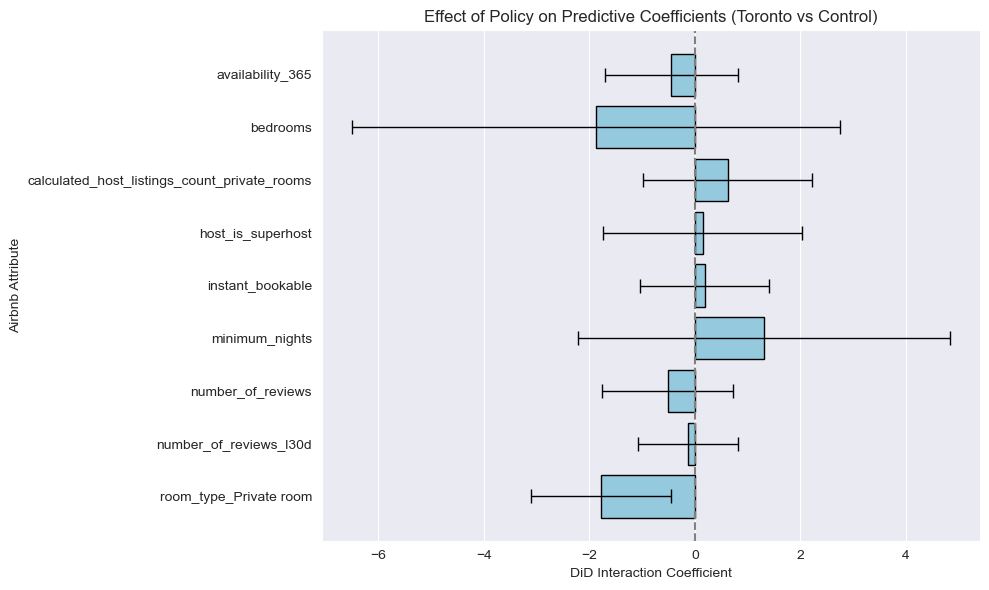

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=did_plot_df, 
    x='coef', 
    y='interaction', 
    orient='h', 
    color='skyblue', 
    edgecolor='k'
)
# Add error bars for the confidence intervals
for bar, se in zip(ax.patches, did_plot_df['se']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.errorbar(
        x=x,
        y=y,
        xerr=1.96 * se,
        fmt='none',
        ecolor='k',
        capsize=5,
        elinewidth=1
    )

plt.axvline(0, linestyle='--', color='grey')
plt.title('Effect of Policy on Predictive Coefficients (Toronto vs Control)')
plt.xlabel('DiD Interaction Coefficient')
plt.ylabel('Airbnb Attribute')
plt.tight_layout()
plt.show()


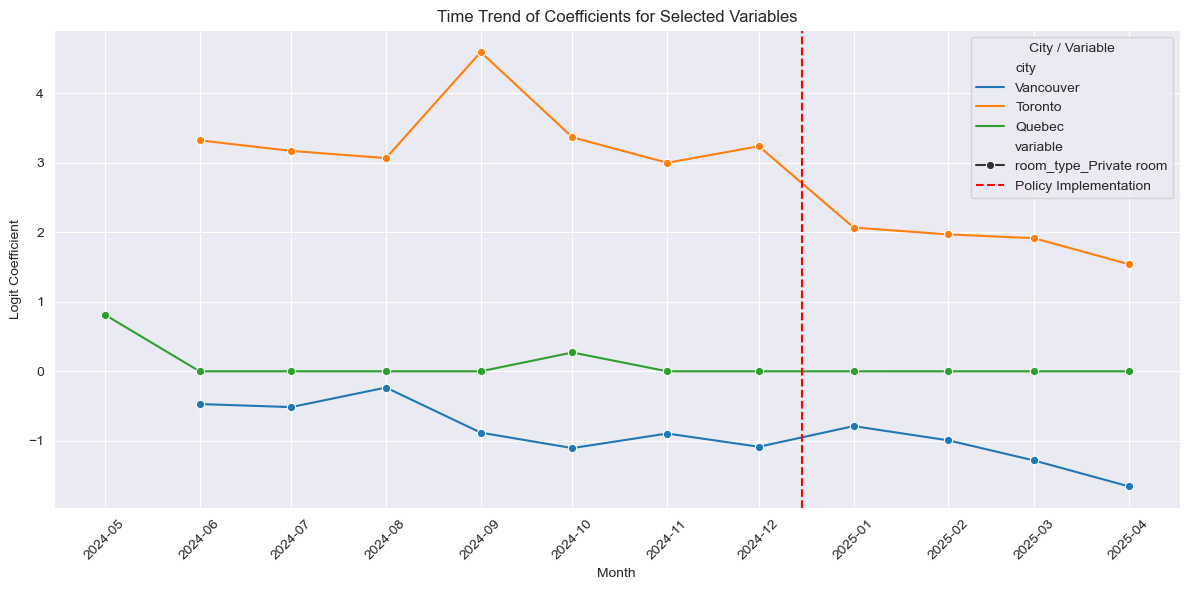

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates

# select the variables you want to plot
selected_vars = ['room_type_Private room']
#selected_vars = ['room_type_Private room', 'availability_365']
plot_df = did_df[did_df['variable'].isin(selected_vars)].copy()


plot_df['time'] = pd.to_datetime(plot_df['time'])

 
all_months = pd.date_range(start=plot_df['time'].min(), end=plot_df['time'].max(), freq='MS')


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x='time',
    y='coef',
    hue='city',           # colored by city
    style='variable',     # style by variable
    markers=True,
    dashes=False
)

# implementation date line:2024-12-31
plt.axvline(pd.to_datetime('2024-12-15'), color='red', linestyle='--', label='Policy Implementation')

# set the x-axis to show all months
plt.xticks(all_months, [dt.strftime('%Y-%m') for dt in all_months], rotation=45)

plt.title('Time Trend of Coefficients for Selected Variables')
plt.ylabel('Logit Coefficient')
plt.xlabel('Month')
plt.legend(title='City / Variable')
plt.tight_layout()
plt.show()
